## Import libraries and data loader

In [27]:
import pandas as pd 
import numpy as np

In [28]:
kp_fish_path = pd.read_csv('../dataset/gbif_asia/gbif_asia_katsuwonus_pelamis.csv')
pa_fish_path = pd.read_csv('../dataset/gbif_asia/gbif_asia_pampus_argenteus.csv')
sc_fish_path = pd.read_csv('../dataset/gbif_asia/gbif_asia_scomberomorus_commerson.csv')
ta_fish_path = pd.read_csv('../dataset/gbif_asia/gbif_asia_thunnus_albacares.csv')
tl_fish_path = pd.read_csv('../dataset/gbif_asia/gbif_asia_trichiurus_lepturus.csv')

In [29]:
# Read and concat to get gbif_data
gbif_data = pd.concat([kp_fish_path, pa_fish_path, sc_fish_path, ta_fish_path, tl_fish_path], ignore_index=True)

In [30]:
print(gbif_data.columns.tolist())

['key', 'datasetKey', 'publishingOrgKey', 'installationKey', 'hostingOrganizationKey', 'publishingCountry', 'protocol', 'lastCrawled', 'lastParsed', 'crawlId', 'extensions', 'basisOfRecord', 'occurrenceStatus', 'classifications', 'taxonKey', 'kingdomKey', 'phylumKey', 'orderKey', 'familyKey', 'genusKey', 'speciesKey', 'acceptedTaxonKey', 'scientificName', 'scientificNameAuthorship', 'acceptedScientificName', 'kingdom', 'phylum', 'order', 'family', 'genus', 'species', 'genericName', 'specificEpithet', 'taxonRank', 'taxonomicStatus', 'iucnRedListCategory', 'dateIdentified', 'decimalLatitude', 'decimalLongitude', 'continent', 'stateProvince', 'gadm', 'year', 'month', 'day', 'eventDate', 'startDayOfYear', 'endDayOfYear', 'issues', 'modified', 'lastInterpreted', 'references', 'license', 'isSequenced', 'identifiers', 'media', 'facts', 'relations', 'isInCluster', 'datasetName', 'recordedBy', 'identifiedBy', 'dnaSequenceID', 'geodeticDatum', 'countryCode', 'recordedByIDs', 'identifiedByIDs', '

In [31]:
print(gbif_data.shape)

(1279, 179)


In [32]:
# filter columns
filtered_columns = ['scientificName',
                    'taxonKey',
                    'individualCount', # The number of individuals represented at the time of occurrence
                    'organismQuantity', # The number or enumeration value for the quantity of organisms
                    'organismQuantityType', # The type of quantity of organisms (e.g., mass, volume, etc.)
                    'sex', # the sex of the biological individual(s) represented in the occurrence
                    'lifeStage', # The life stage or developmental stage of the biological individual(s) represented in the occurrence
                    'occurrenceStatus', # Present for yes, absent for no, mostly present

                    ### Locations
                    'continent',
                    'countryCode',
                    'stateProvince',
                    'island',
                    'decimalLatitude',
                    'decimalLongitude',
                    'elevation',
                    'elevationAccuracy',
                    'coordinateUncertaintyInMeters',

                    ## Date
                    'eventDate',
                    'year',
                    'month',
                    'day'
]
gbif_data_subset = gbif_data[filtered_columns]

In [ ]:
# Save CSV file
# gbif_data_subset.to_csv('../dataset/gbif_five_species_asia_cleaned.csv', index=False)

In [34]:
print(gbif_data_subset.head(5))

                        scientificName  taxonKey  individualCount  \
0  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
1  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
2  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
3  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
4  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   

   organismQuantity organismQuantityType  sex lifeStage occurrenceStatus  \
0               NaN                  NaN  NaN       NaN          PRESENT   
1               NaN                  NaN  NaN       NaN          PRESENT   
2               NaN                  NaN  NaN       NaN          PRESENT   
3               NaN                  NaN  NaN       NaN          PRESENT   
4               NaN                  NaN  NaN       NaN          PRESENT   

  continent countryCode  ... island decimalLatitude  decimalLongitude  \
0      ASIA          TW  ...    NaN       25.128225    

In [35]:
print(gbif_data_subset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   scientificName                 1279 non-null   object 
 1   taxonKey                       1279 non-null   int64  
 2   individualCount                236 non-null    float64
 3   organismQuantity               25 non-null     float64
 4   organismQuantityType           25 non-null     object 
 5   sex                            34 non-null     object 
 6   lifeStage                      112 non-null    object 
 7   occurrenceStatus               1279 non-null   object 
 8   continent                      1279 non-null   object 
 9   countryCode                    1279 non-null   object 
 10  stateProvince                  696 non-null    object 
 11  island                         64 non-null     object 
 12  decimalLatitude                1279 non-null   f

In [36]:
print(gbif_data_subset.describe())

           taxonKey  individualCount  organismQuantity  decimalLatitude  \
count  1.279000e+03       236.000000         25.000000      1279.000000   
mean   2.712932e+06         1.614407          2.480000        18.864253   
std    1.570413e+06         3.033088          2.663331        14.290911   
min    2.374013e+06         0.000000          1.000000       -10.589459   
25%    2.374191e+06         1.000000          1.000000         5.616417   
50%    2.389407e+06         1.000000          1.000000        22.791816   
75%    2.397682e+06         1.000000          3.000000        32.427916   
max    1.064263e+07        40.000000          9.000000        46.698818   

       decimalLongitude  elevation  elevationAccuracy  \
count       1279.000000  25.000000               25.0   
mean         107.558694   0.668000                0.0   
std           27.950824   1.619341                0.0   
min           28.238995   0.000000                0.0   
25%           98.669300   0.000000     

In [37]:
# Unique value of categorical columns
categorical_columns = ['scientificName','taxonKey', 'organismQuantityType', 'sex', 'lifeStage', 'occurrenceStatus', 'continent', 'countryCode', 'stateProvince', 'island']
for col in categorical_columns:
    unique_values = gbif_data_subset[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")

Unique values in column 'scientificName': ['Katsuwonus pelamis (Linnaeus, 1758)' 'BOLD:AAA5421'
 'Pampus argenteus (Euphrasen, 1788)' 'Pampus cinereus (Bloch, 1795)'
 'Stromateus cinereus Bloch, 1795'
 'Stromateoides argenteus (Euphrasen, 1788)'
 'Scomberomorus commerson (Lacepède, 1800)' 'BOLD:AAB5512' 'BOLD:AAB5513'
 'Thunnus albacares (Bonnaterre, 1788)'
 'Neothunnus macropterus (Temminck & Schlegel, 1844)'
 'Trichiurus lepturus Linnaeus, 1758'
 'Trichiurus japonicus Temminck & Schlegel, 1844' 'BOLD:ACP1370'
 'BOLD:AAB0171']
Unique values in column 'taxonKey': [ 2374191  9877823  2397682  2397674  2397675  2397679  2374255 10433110
  9855923  2374013  2374027  2389407  2389414 10152751 10642633]
Unique values in column 'organismQuantityType': [nan 'individuals' 'DNA Sequence reads']
Unique values in column 'sex': [nan 'Indeterminate' 'Female']
Unique values in column 'lifeStage': [nan 'Adult' 'Larva' 'Juvenile' 'Egg']
Unique values in column 'occurrenceStatus': ['PRESENT']
Unique va

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, 'Pampus argenteus (Euphrasen, 1788)'),
  Text(1, 0, 'Scomberomorus commerson (Lacepède, 1800)'),
  Text(2, 0, 'Katsuwonus pelamis (Linnaeus, 1758)'),
  Text(3, 0, 'Trichiurus japonicus Temminck & Schlegel, 1844'),
  Text(4, 0, 'Thunnus albacares (Bonnaterre, 1788)'),
  Text(5, 0, 'Trichiurus lepturus Linnaeus, 1758'),
  Text(6, 0, 'BOLD:AAB5512'),
  Text(7, 0, 'BOLD:AAA5421'),
  Text(8, 0, 'Pampus cinereus (Bloch, 1795)'),
  Text(9, 0, 'BOLD:AAB5513'),
  Text(10, 0, 'BOLD:AAB0171'),
  Text(11, 0, 'Neothunnus macropterus (Temminck & Schlegel, 1844)'),
  Text(12, 0, 'Stromateus cinereus Bloch, 1795'),
  Text(13, 0, 'Stromateoides argenteus (Euphrasen, 1788)'),
  Text(14, 0, 'BOLD:ACP1370')])

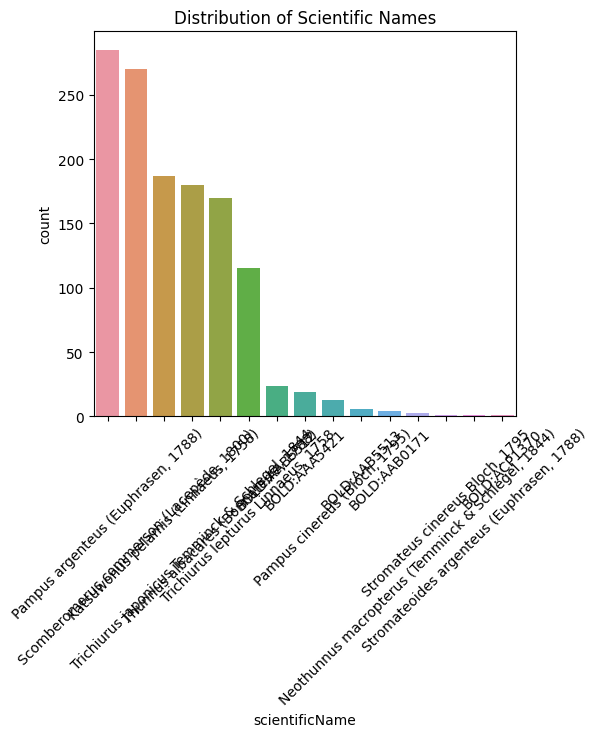

In [38]:
# Plot distribution of scientificName, occurrenceStatus
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gbif_data_subset, x='scientificName', order=gbif_data_subset['scientificName'].value_counts().index)
plt.title('Distribution of Scientific Names')
plt.xticks(rotation=45)

(array([0]), [Text(0, 0, 'PRESENT')])

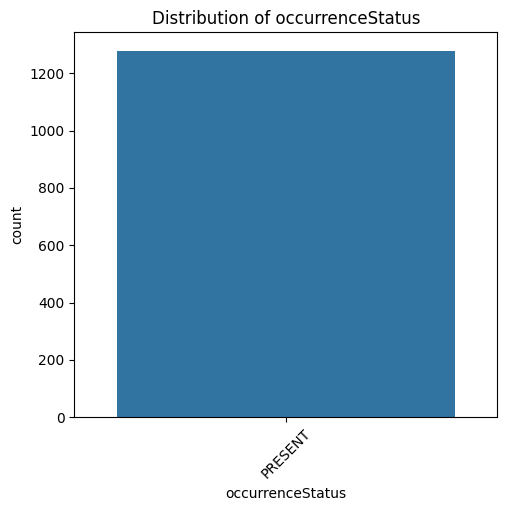

In [39]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gbif_data_subset, x='occurrenceStatus', order=gbif_data_subset['occurrenceStatus'].value_counts().index)
plt.title('Distribution of occurrenceStatus')
plt.xticks(rotation=45)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Adult'),
  Text(1, 0, 'Egg'),
  Text(2, 0, 'Larva'),
  Text(3, 0, 'Juvenile')])

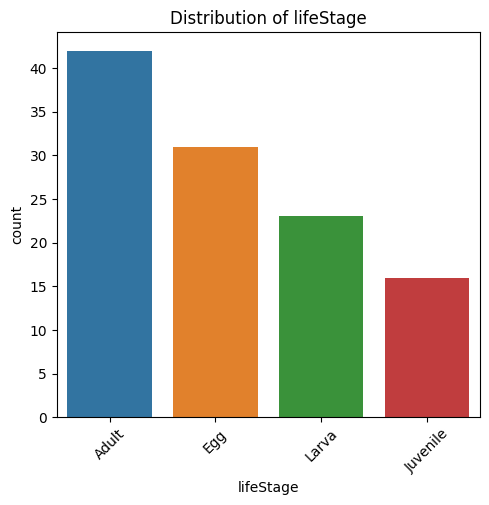

In [40]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gbif_data_subset, x='lifeStage', order=gbif_data_subset['lifeStage'].value_counts().index)
plt.title('Distribution of lifeStage')
plt.xticks(rotation=45)

In [52]:
gbif_data_subset = gbif_data_subset[gbif_data_subset['year'] >= 2000]

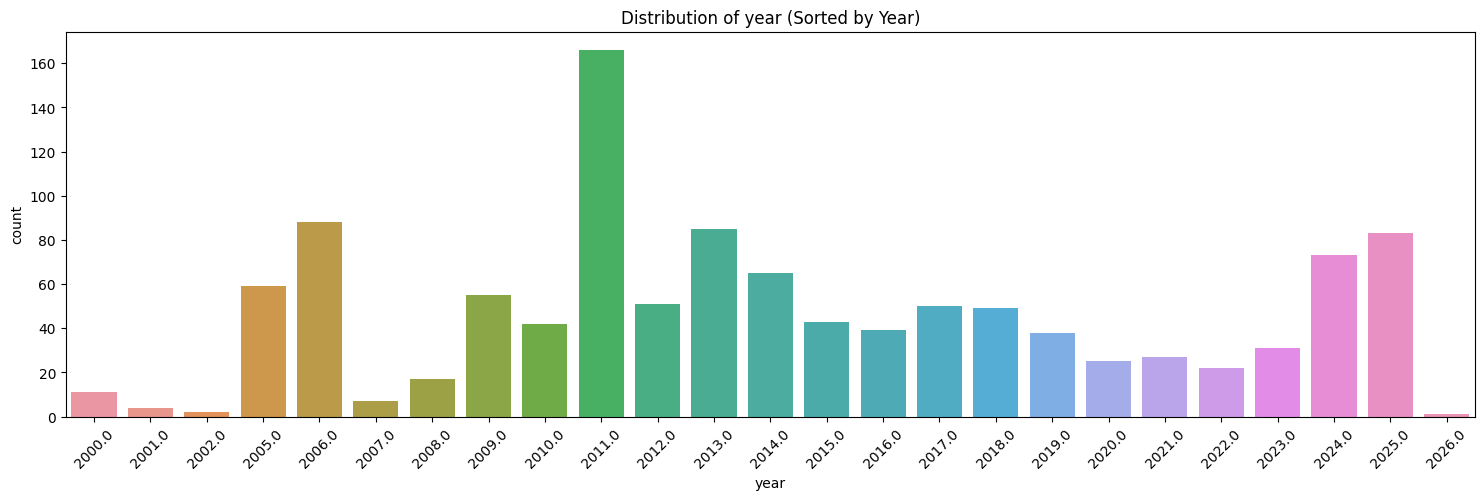

In [53]:
plt.figure(figsize=(40, 5))
plt.subplot(1, 2, 1)

# Sắp xếp các giá trị unique của năm theo thứ tự tăng dần
sorted_years = sorted(gbif_data_subset['year'].unique())

sns.countplot(
    data=gbif_data_subset, 
    x='year', 
    order=sorted_years
)

plt.title('Distribution of year (Sorted by Year)')
plt.xticks(rotation=45)
plt.show()

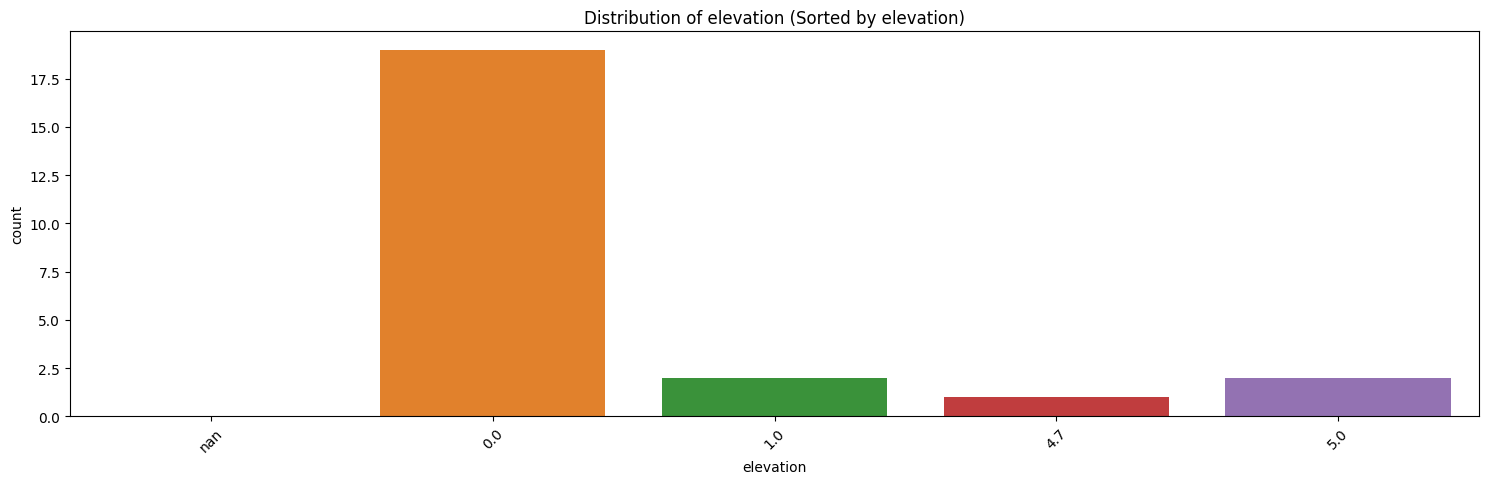

In [54]:
plt.figure(figsize=(40, 5))
plt.subplot(1, 2, 1)

# Sắp xếp các giá trị unique của năm theo thứ tự tăng dần
sorted_years = sorted(gbif_data_subset['elevation'].unique())

sns.countplot(
    data=gbif_data_subset, 
    x='elevation', 
    order=sorted_years
)

plt.title('Distribution of elevation (Sorted by elevation)')
plt.xticks(rotation=45)
plt.show()

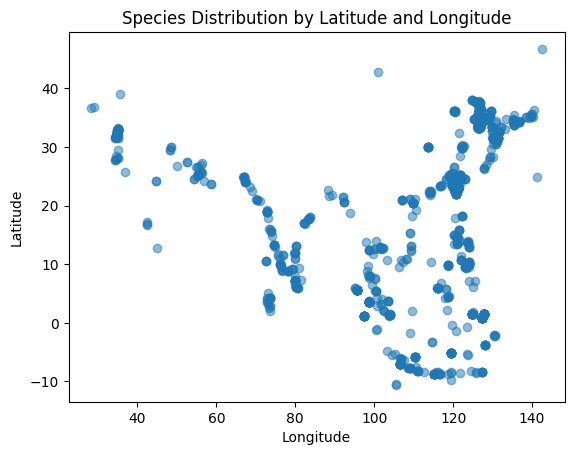

In [42]:
# distribution by lat long
import matplotlib.pyplot as plt
plt.scatter(gbif_data_subset['decimalLongitude'], gbif_data_subset['decimalLatitude'], alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Species Distribution by Latitude and Longitude')
plt.show()

In [43]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)


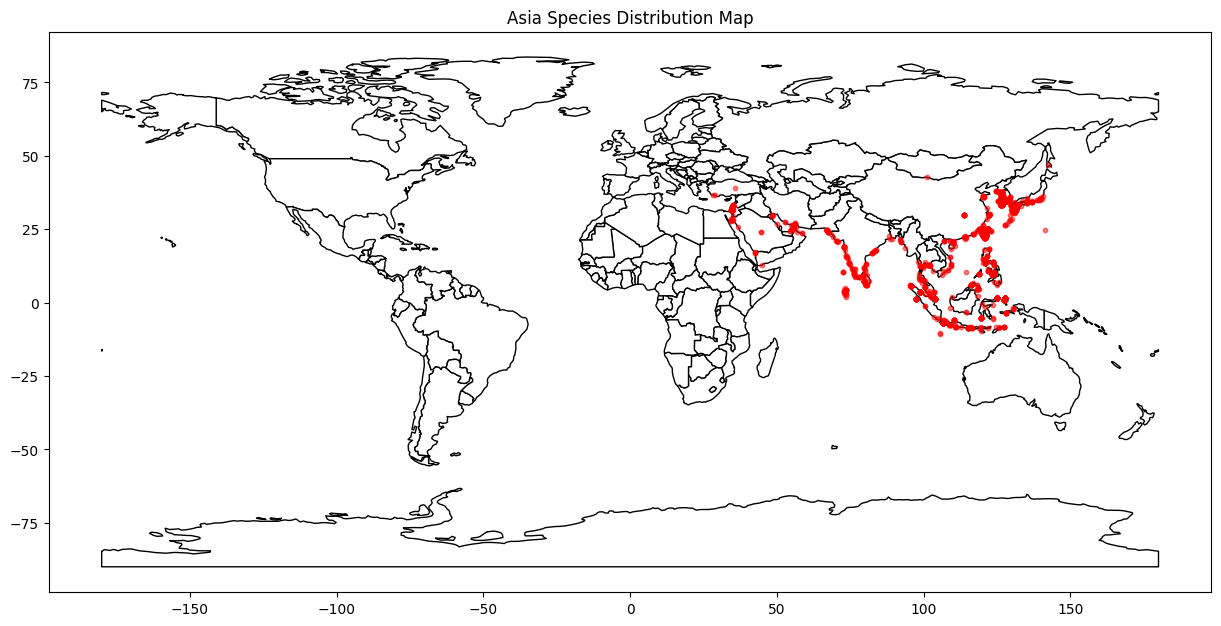

In [44]:
# Add map visualization
import geopandas as gpd
from shapely.geometry import Point 
geometry = [Point(xy) for xy in zip(gbif_data_subset['decimalLongitude'], gbif_data_subset['decimalLatitude'])]
geo_df = gpd.GeoDataFrame(gbif_data_subset, geometry=geometry)
world = gpd.read_file(url)
ax = world.plot(figsize=(15, 10), color='white', edgecolor='black')
geo_df.plot(ax=ax, markersize=10, color='red', alpha=0.5)
plt.title('Asia Species Distribution Map')
plt.show()

## Lat-lon of merge file

In [45]:
#merge file path
merge_path = '../dataset/gbif_five_species_asia_cleaned.csv'
merge_df = pd.read_csv(merge_path)
print(merge_df.head(5))

                        scientificName  taxonKey  individualCount  \
0  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
1  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
2  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
3  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
4  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   

   organismQuantity organismQuantityType  sex lifeStage occurrenceStatus  \
0               NaN                  NaN  NaN       NaN          PRESENT   
1               NaN                  NaN  NaN       NaN          PRESENT   
2               NaN                  NaN  NaN       NaN          PRESENT   
3               NaN                  NaN  NaN       NaN          PRESENT   
4               NaN                  NaN  NaN       NaN          PRESENT   

  continent countryCode  ... island decimalLatitude  decimalLongitude  \
0      ASIA          TW  ...    NaN       25.128225    

In [46]:
# remove rows with year less than 2000
merge_df = merge_df[merge_df['year'] >= 2000]
print(merge_df.shape)

(1133, 21)


In [47]:
print(merge_df.describe())

           taxonKey  individualCount  organismQuantity  decimalLatitude  \
count  1.133000e+03       171.000000         14.000000      1133.000000   
mean   2.721667e+06         1.473684          1.571429        19.144518   
std    1.595098e+06         3.277940          2.138090        14.541415   
min    2.374013e+06         0.000000          1.000000       -10.589459   
25%    2.374191e+06         1.000000          1.000000         5.616417   
50%    2.374255e+06         1.000000          1.000000        23.098756   
75%    2.389414e+06         1.000000          1.000000        32.793177   
max    1.064263e+07        40.000000          9.000000        46.698818   

       decimalLongitude  elevation  elevationAccuracy  \
count       1133.000000  24.000000               24.0   
mean         108.151574   0.695833                0.0   
std           28.097532   1.648050                0.0   
min           28.238995   0.000000                0.0   
25%           98.669300   0.000000     

**Formating time, lat, long columns to mapping with corpenius**

Corpenius data format requires:
- Time: datetime64[ns], daily/hourly
- Latitude: float (-90 -> 90)
- Longtitude: 0-360 (instead of -180 -> 180)


In [50]:
# Count unique value of column year
merge_df['year'].value_counts()


year
2011.0    166
2006.0     88
2013.0     85
2025.0     83
2024.0     73
2014.0     65
2005.0     59
2009.0     55
2012.0     51
2017.0     50
2018.0     49
2015.0     43
2010.0     42
2016.0     39
2019.0     38
2023.0     31
2021.0     27
2020.0     25
2022.0     22
2008.0     17
2000.0     11
2007.0      7
2001.0      4
2002.0      2
2026.0      1
Name: count, dtype: int64